# 1,9 cm con un caliper. 3,2 cm en la imagen. ¿Cuál le cree su médico?

Lo que el pellizco no ve bajo la piel.

---

**Paper**: [Whole cross-sectional human ultrasound tomography](https://doi.org/10.1038/s41551-026-01660-4)
*Yang et al., Nature Biomedical Engineering, 2026*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-24-ultrasonido-tomografia-corte-completo/notebook.ipynb)

Video YouTube: *pendiente*

## Qué hicieron

Los autores construyeron un aro de 60 cm con 512 receptores y un transmisor que gira. La persona se sienta, mete el torso en un tanque de agua, y el sistema genera una imagen del corte transversal completo — como una TAC, pero con ultrasonido y sin radiación.

Para saber si las imágenes son confiables, el equipo hizo tres validaciones en cadena: primero con líquido de velocidad conocida (mezclas etanol-agua), luego con un fantasma de grasa sintética (manteca sobre agar), y al final contra resonancia magnética en humanos.

Nosotros reproducimos esas tres validaciones con las tablas del Supplementary. No reconstruimos las imágenes (el código es propietario y los datos crudos pesan 14 GB) — medimos si las mediciones derivadas de las imágenes coinciden con lo que se esperaba.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuracion — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_ERROR_PCT = 1.0       # Claim del paper: errores tipicos < 1%
FUENTE = 'Fuente: Yang et al. (2026), Nature Biomed. Eng. | Datos: Supplementary Information (MOESM1)'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_SECUNDARIO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_CONTEXTO = '#BBBBBB'

# ══════════════════════════════════════════════════════════════
# Imports + estilo CaM
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

# ══════════════════════════════════════════════════════════════
# Cargar datasets del Supplementary
# ══════════════════════════════════════════════════════════════
etanol = pd.read_csv('datos/ethanol_validacion.csv')
fantasma = pd.read_csv('datos/adipose_fantasma.csv')
mri = pd.read_csv('datos/adipose_ust_vs_mri.csv')
calipers = pd.read_csv('datos/adipose_calipers_vs_ust.csv')

print(f'Etanol-agua (5 concentraciones):  {len(etanol)} filas')
print(f'Fantasma de grasa (2 espesores):  {len(fantasma)} filas')
print(f'UST vs MRI (6 lineas de perfil):  {len(mri)} filas')
print(f'Calipers vs UST (2 voluntarios):  {len(calipers)} filas')
print()
print('Primeras filas ethanol:')
print(etanol.to_string(index=False))

Etanol-agua (5 concentraciones):  5 filas
Fantasma de grasa (2 espesores):  2 filas
UST vs MRI (6 lineas de perfil):  6 filas
Calipers vs UST (2 voluntarios):  4 filas

Primeras filas ethanol:
 ethanol_pct  referencia_vel_ms  referencia_se_ms  unmasked_vel_ms  unmasked_err_pct  masked_vel_ms  masked_err_pct
           5             1508.6              0.18           1511.0              0.15        1509.39            0.04
          10             1532.4              0.24           1524.5             -0.52        1542.04            0.63
          20             1578.9              0.26           1580.2              0.08        1578.83            0.00
          50             1609.5              0.50           1604.2             -0.33        1563.77           -2.84
          60             1531.4              0.18           1508.1             -1.52        1520.03           -0.74


## Validación 1 — Líquido conocido

Aquí está.

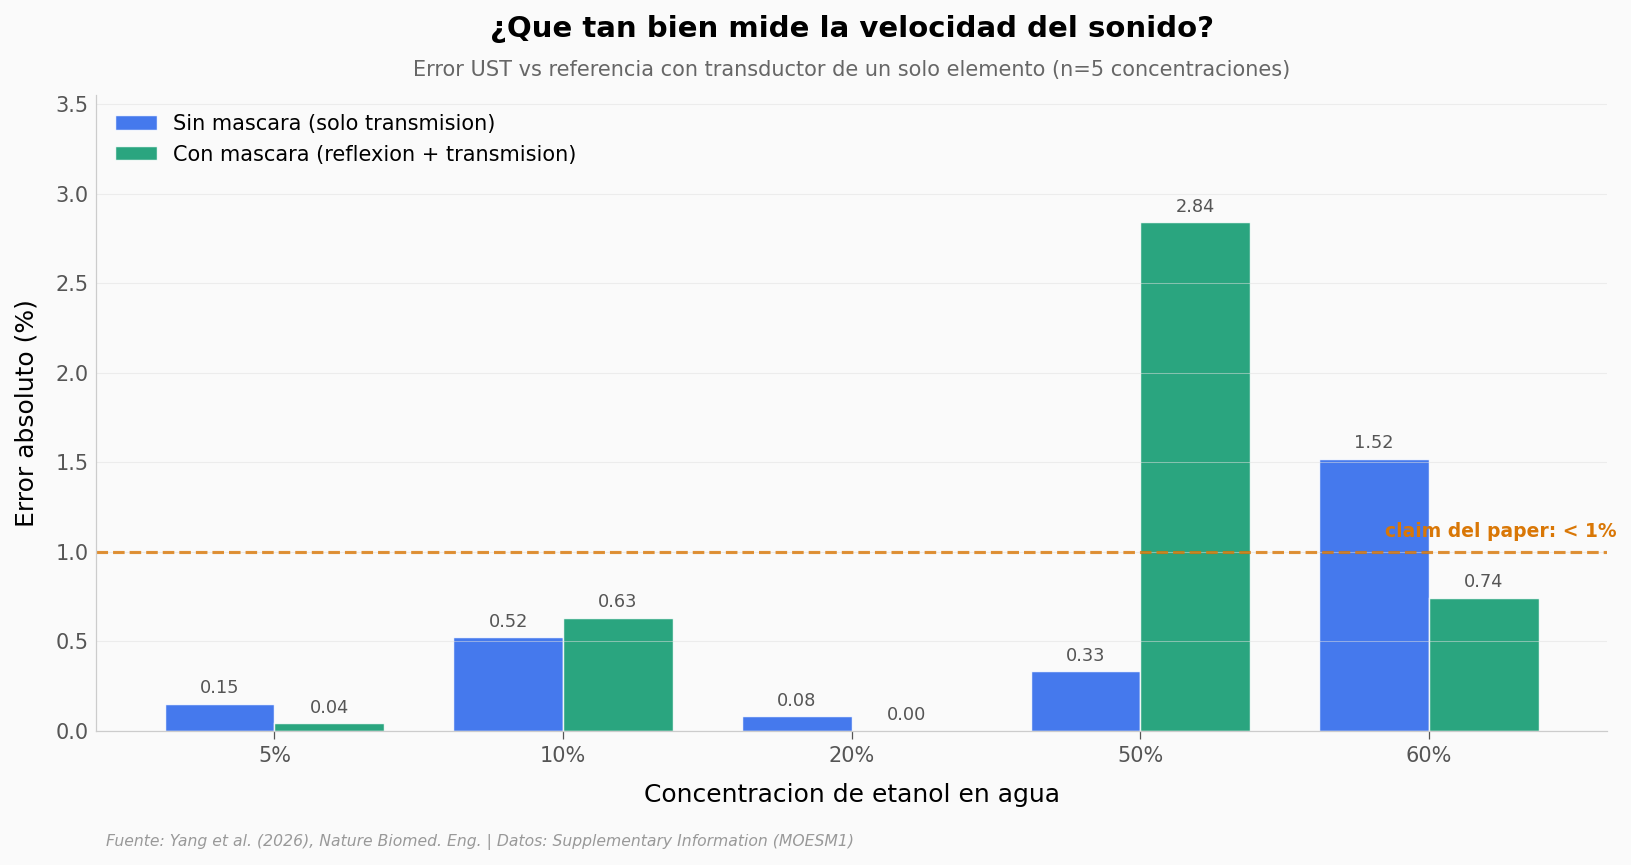

Sin mascara — promedio: 0.52%  |  maximo: 1.52%
Con mascara — promedio: 0.85%  |  maximo: 2.84%
Concentraciones bajo 1%: unmasked 4/5, masked 4/5


In [2]:
# Gráfica hero: errores absolutos UST en 5 mezclas etanol-agua
fig, ax = plt.subplots(figsize=(13, 5.5))

pct = etanol['ethanol_pct'].values
err_unmasked = np.abs(etanol['unmasked_err_pct'].values)
err_masked = np.abs(etanol['masked_err_pct'].values)

x = np.arange(len(pct))
w = 0.38
bars1 = ax.bar(x - w/2, err_unmasked, w, color=COLOR_DATOS, alpha=0.85,
               edgecolor='white', linewidth=0.7, label='Sin mascara (solo transmision)')
bars2 = ax.bar(x + w/2, err_masked,   w, color=COLOR_SECUNDARIO, alpha=0.85,
               edgecolor='white', linewidth=0.7, label='Con mascara (reflexion + transmision)')

ax.axhline(UMBRAL_ERROR_PCT, color=COLOR_REFERENCIA, linewidth=1.5,
           linestyle='--', alpha=0.8)
ax.text(len(pct) - 0.35, UMBRAL_ERROR_PCT + 0.08,
        f'claim del paper: < {UMBRAL_ERROR_PCT:.0f}%',
        fontsize=9, color=COLOR_REFERENCIA, ha='right', fontweight='bold')

# Etiquetas sobre cada barra
for bar, val in zip(list(bars1) + list(bars2), list(err_unmasked) + list(err_masked)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.06,
            f'{val:.2f}', ha='center', fontsize=8.5, color='#555')

ax.set_xticks(x)
ax.set_xticklabels([f'{int(p)}%' for p in pct])
ax.set_xlabel('Concentracion de etanol en agua')
ax.set_ylabel('Error absoluto (%)')
ax.set_title('¿Que tan bien mide la velocidad del sonido?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Error UST vs referencia con transductor de un solo elemento (n=5 concentraciones)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, max(err_unmasked.max(), err_masked.max()) * 1.25)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_etanol_errores.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen numerico
print(f'Sin mascara — promedio: {err_unmasked.mean():.2f}%  |  maximo: {err_unmasked.max():.2f}%')
print(f'Con mascara — promedio: {err_masked.mean():.2f}%  |  maximo: {err_masked.max():.2f}%')
print(f'Concentraciones bajo 1%: unmasked {int((err_unmasked < 1).sum())}/5, masked {int((err_masked < 1).sum())}/5')

Lo que llama la atención: en 4 de 5 concentraciones, ambas reconstrucciones caen bajo el umbral que el paper declara como típico. El caso 50% etanol es el único que rompe la norma en la versión con máscara — 2,84% de error, casi el doble del peor caso sin máscara.

¿Por qué? Cuando la concentración de etanol pasa el 50%, la velocidad del sonido deja de subir monótonamente y empieza a bajar (el líquido cambia de régimen). La versión con máscara depende de una segmentación previa basada en reflexión, y esa segmentación no está pensada para este tipo de discontinuidad. La versión sin máscara lo maneja mejor porque opera sobre toda la señal sin asumir dónde están los límites.

Traducción: ambas versiones funcionan para tejido humano (donde las velocidades están en el rango 1450–1600 m/s y no saltan así). La versión con máscara es más precisa en el caso fácil y falla peor en el caso raro.

## Validación 2 — Fantasma de grasa

Del líquido pasamos al fantasma: un núcleo de agar-agar con una capa de manteca por encima. Dos lados, dos espesores conocidos medidos con cinta plástica antes del experimento — 1,00 cm y 2,00 cm. La pregunta es directa: ¿cuánto mide el UST?

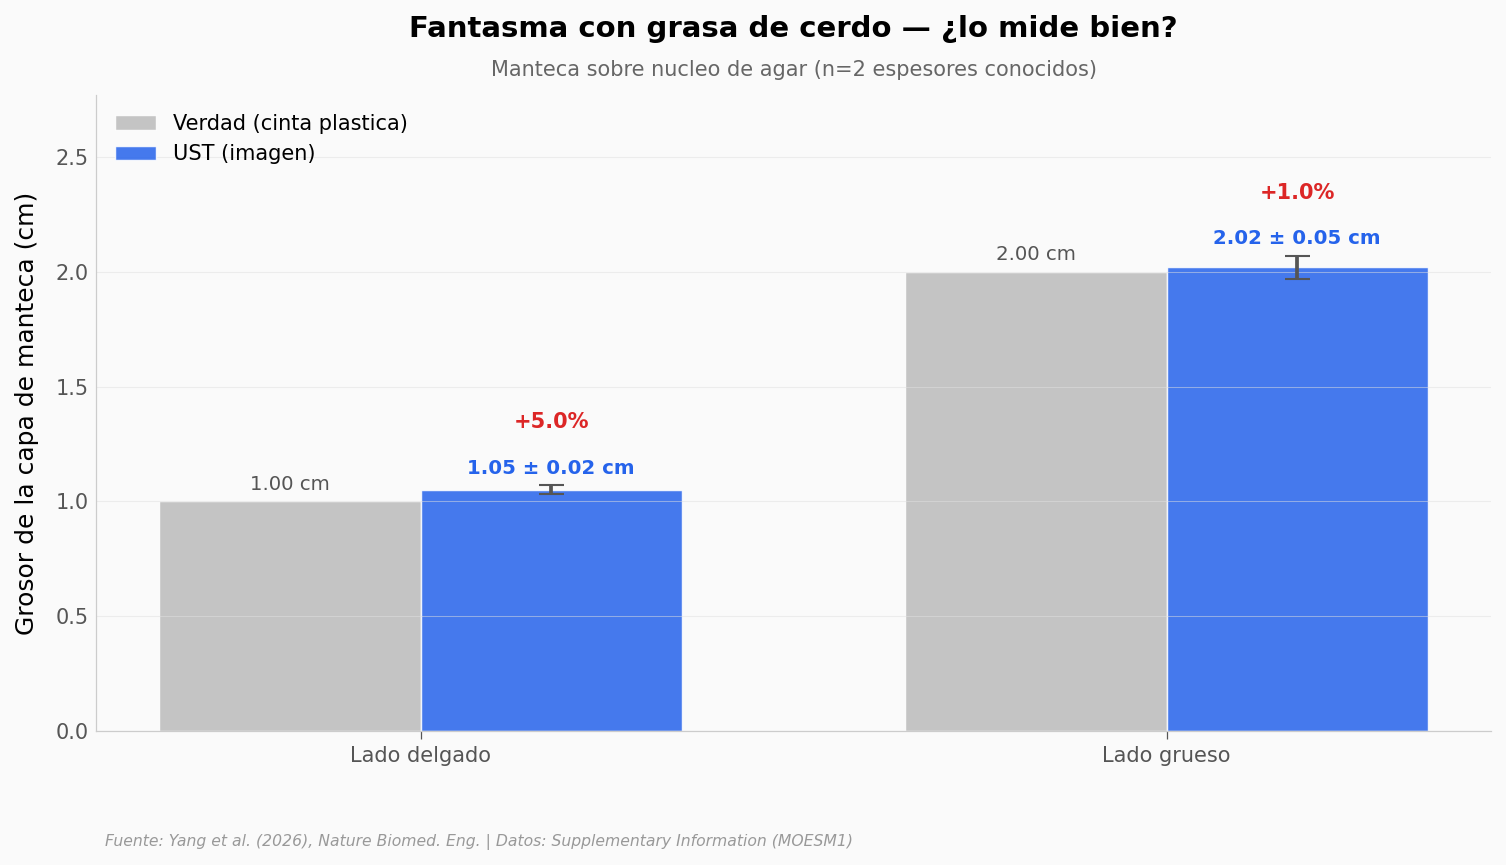

Sobreestimacion: delgado +5.0%, grueso +1.0%
Promedio: +3.0%  (paper reporta ~3%)

Razon: la velocidad del sonido en manteca (~1440 m/s) es menor que en agua (~1483 m/s).
El algoritmo asume velocidad del agua — al no corregir, el grosor se infla ~3%.


In [3]:
# Fantasma: ground truth (cinta) vs UST con incertidumbre
fig, ax = plt.subplots(figsize=(12, 5.5))

labels = ['Lado delgado', 'Lado grueso']
gt = fantasma['ground_truth_cm'].values
ust = fantasma['ust_estimacion_cm'].values
err = fantasma['ust_incertidumbre_cm'].values

x = np.arange(len(labels))
w = 0.35
bars_gt = ax.bar(x - w/2, gt, w, color=COLOR_CONTEXTO, alpha=0.85,
                 edgecolor='white', linewidth=0.7, label='Verdad (cinta plastica)')
bars_ust = ax.bar(x + w/2, ust, w, yerr=err, color=COLOR_DATOS, alpha=0.85,
                  edgecolor='white', linewidth=0.7, capsize=6, ecolor='#555',
                  label='UST (imagen)')

# Valores numericos encima de cada barra
for bar, val in zip(bars_gt, gt):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val:.2f} cm', ha='center', fontsize=9.5, color='#555')
for bar, val, e in zip(bars_ust, ust, err):
    ax.text(bar.get_x() + bar.get_width()/2, val + e + 0.05,
            f'{val:.2f} ± {e:.2f} cm', ha='center', fontsize=9.5,
            color=COLOR_DATOS, fontweight='bold')

# Sobreestimacion %
for i, (g, u) in enumerate(zip(gt, ust)):
    pct = (u - g) / g * 100
    ax.annotate(f'+{pct:.1f}%', xy=(i + w/2, u + err[i] + 0.25),
                ha='center', fontsize=10, color=COLOR_ALERTA, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Grosor de la capa de manteca (cm)')
ax.set_title('Fantasma con grasa de cerdo — ¿lo mide bien?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Manteca sobre nucleo de agar (n=2 espesores conocidos)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, max(ust) + max(err) + 0.7)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_fantasma.png', dpi=200, bbox_inches='tight')
plt.show()

# Sobreestimacion promedio
overestim = ((ust - gt) / gt * 100)
print(f'Sobreestimacion: delgado +{overestim[0]:.1f}%, grueso +{overestim[1]:.1f}%')
print(f'Promedio: +{overestim.mean():.1f}%  (paper reporta ~3%)')
print()
print('Razon: la velocidad del sonido en manteca (~1440 m/s) es menor que en agua (~1483 m/s).')
print('El algoritmo asume velocidad del agua — al no corregir, el grosor se infla ~3%.')

## Validación 3 — Humanos de verdad

Las dos validaciones anteriores son "laboratorio limpio": líquido puro, fantasma sintético, espesores conocidos. En cuerpo humano no hay cinta plástica para medir — la única referencia comparable es la resonancia magnética (MRI), que mide grosor de grasa con física distinta.

El equipo escogió 6 líneas de perfil en 3 planos abdominales del mismo voluntario, midió grosor de grasa subcutánea con UST (sentado, torso en agua) y con MRI 3T (acostado), y comparó.

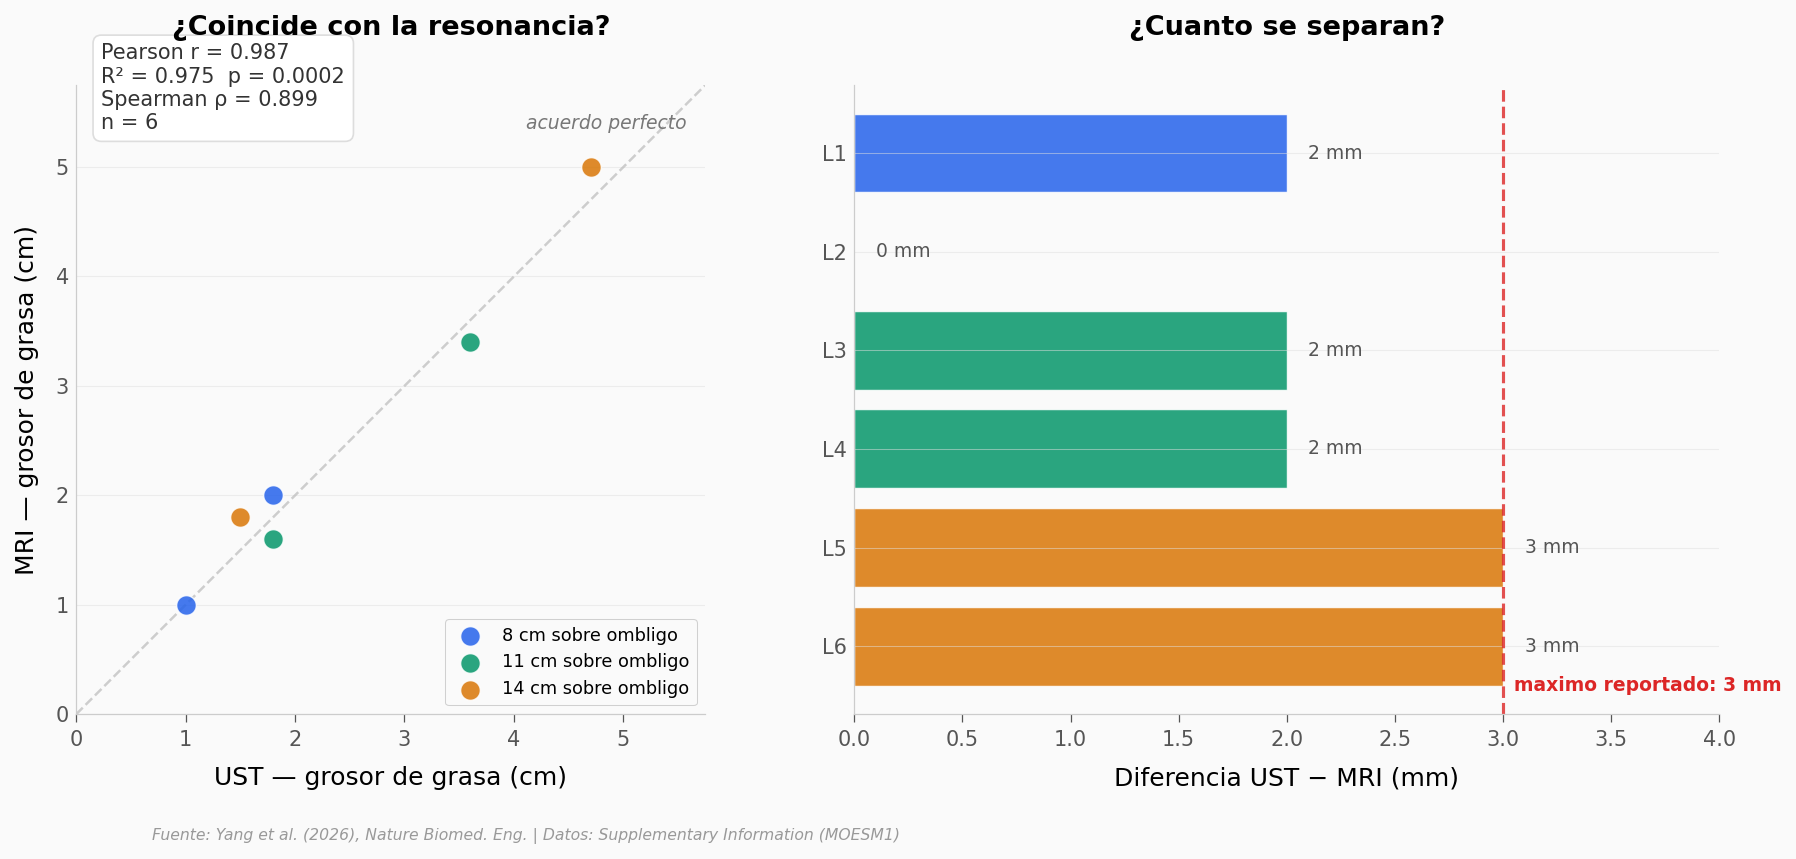

Shapiro-Wilk UST: p=0.197  |  MRI: p=0.281  (p>0.05 = no descarta normalidad)
Pearson r = 0.987 (paper reporta 0.987), R² = 0.975, p = 0.0002
Spearman ρ = 0.899  (robusto a no-normalidad, consistente)
Diferencia maxima: 3 mm  |  promedio abs: 2.0 mm
Nota: n=6 es pequeño. La correlacion alta es consistente con el paper,
pero los limites de acuerdo Bland-Altman reportados ([-5,2; 3,9] mm) dan el panorama real.


In [4]:
# UST vs MRI: scatter con linea identidad y correlacion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5),
                                gridspec_kw={'width_ratios': [1, 1]})

# Panel izquierdo: scatter UST vs MRI con linea y=x
ust_v = mri['ust_cm'].values
mri_v = mri['mri_cm'].values
planos = mri['plano'].unique()
colores_plano = {'plano_a_8cm': COLOR_DATOS, 'plano_a_11cm': COLOR_SECUNDARIO,
                 'plano_a_14cm': COLOR_REFERENCIA}
etiquetas_plano = {'plano_a_8cm': '8 cm sobre ombligo',
                   'plano_a_11cm': '11 cm sobre ombligo',
                   'plano_a_14cm': '14 cm sobre ombligo'}

lim = [0, max(ust_v.max(), mri_v.max()) * 1.15]
ax1.plot(lim, lim, color=COLOR_CONTEXTO, linewidth=1.2, linestyle='--',
         alpha=0.7, zorder=2)
ax1.text(lim[1] * 0.97, lim[1] * 0.93, 'acuerdo perfecto',
         fontsize=9, color='#777', ha='right', style='italic')

for plano in planos:
    sub = mri[mri['plano'] == plano]
    ax1.scatter(sub['ust_cm'], sub['mri_cm'], s=90,
                color=colores_plano[plano], alpha=0.85,
                edgecolors='white', linewidths=0.7, zorder=5,
                label=etiquetas_plano[plano])

# Correlacion Pearson (paper reporta r=0.987)
# Con n=6, Pearson y Spearman son casi identicos; usamos Pearson como el paper.
# Verificacion de normalidad antes de Pearson:
sw_ust = stats.shapiro(ust_v)
sw_mri = stats.shapiro(mri_v)
r_p, p_p = stats.pearsonr(ust_v, mri_v)
r_s, p_s = stats.spearmanr(ust_v, mri_v)
ax1.text(0.04, 0.93, f'Pearson r = {r_p:.3f}\nR² = {r_p**2:.3f}  p = {p_p:.4f}\nSpearman ρ = {r_s:.3f}\nn = 6',
         transform=ax1.transAxes, fontsize=10, color='#333',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                   edgecolor='#ddd', linewidth=0.8))

ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel('UST — grosor de grasa (cm)')
ax1.set_ylabel('MRI — grosor de grasa (cm)')
ax1.set_title('¿Coincide con la resonancia?',
              fontsize=13, fontweight='bold', pad=24)
ax1.legend(fontsize=8.5, loc='lower right', frameon=True, framealpha=0.9)
ax1.set_aspect('equal')

# Panel derecho: diferencias en mm
diff = mri['diferencia_mm'].values
lineas = mri['linea'].values
colores_bar = [colores_plano[p] for p in mri['plano'].values]

bars = ax2.barh(lineas, diff, color=colores_bar, alpha=0.85,
                edgecolor='white', linewidth=0.7)
ax2.axvline(3, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.8)
ax2.text(3.05, 5.3, 'maximo reportado: 3 mm', fontsize=9,
         color=COLOR_ALERTA, fontweight='bold', va='top')

for bar, v in zip(bars, diff):
    ax2.text(v + 0.1, bar.get_y() + bar.get_height()/2, f'{int(v)} mm',
             va='center', fontsize=9, color='#555')

ax2.set_xlabel('Diferencia UST − MRI (mm)')
ax2.set_title('¿Cuanto se separan?',
              fontsize=13, fontweight='bold', pad=24)
ax2.set_xlim(0, 4)
ax2.invert_yaxis()

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_ust_vs_mri.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Shapiro-Wilk UST: p={sw_ust.pvalue:.3f}  |  MRI: p={sw_mri.pvalue:.3f}  (p>0.05 = no descarta normalidad)')
print(f'Pearson r = {r_p:.3f} (paper reporta 0.987), R² = {r_p**2:.3f}, p = {p_p:.4f}')
print(f'Spearman ρ = {r_s:.3f}  (robusto a no-normalidad, consistente)')
print(f'Diferencia maxima: {int(diff.max())} mm  |  promedio abs: {diff.mean():.1f} mm')
print('Nota: n=6 es pequeño. La correlacion alta es consistente con el paper,')
print('pero los limites de acuerdo Bland-Altman reportados ([-5,2; 3,9] mm) dan el panorama real.')

## El golpe final — ¿y los calipers que usan en consulta?

Hasta ahora comparamos el UST con referencias que existen por diseño para ser precisas: líquido calibrado, fantasma medido con cinta, resonancia de 3 tesla. Pero en la práctica clínica nadie usa eso para medir grasa subcutánea — usan un caliper de pellizco, una herramienta de $30 que aprieta la piel y mide el doble de la capa.

La suposición implícita es que pellizcar la piel y dividir entre dos da el grosor de la grasa. Esa suposición asume que la grasa no se comprime al pellizcar. Veamos qué pasa cuando se compara con la medición directa del UST.

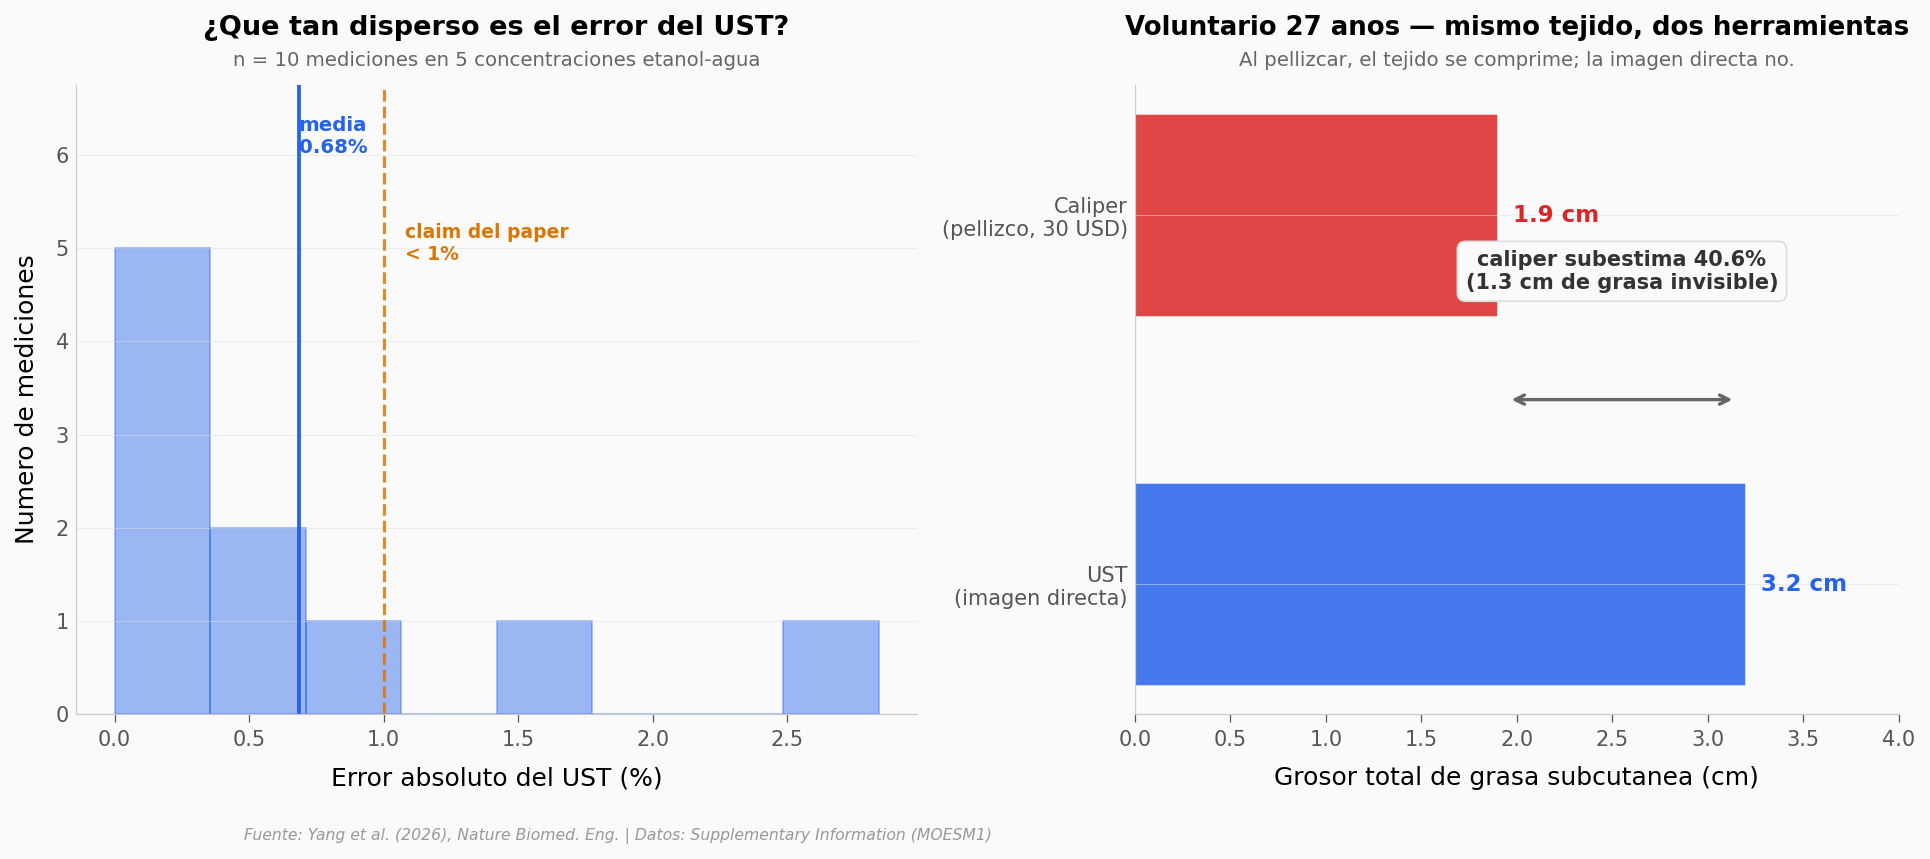

UST velocidad (etanol) — promedio 0.68%, maximo 2.84%  (n=10)
UST grosor (fantasma)  — sobreestimacion promedio 3.00%  (n=2)
Caliper (27a, sujeto grande) — subestima 40.6% respecto al UST (1,3 cm no vistos)

Estos son tres tipos de error distintos — no son comparables numericamente,
pero cuentan la misma historia: el UST valida contra referencias objetivas,
el caliper depende del pellizco.


In [5]:
# Histograma de anomalia: errores UST validados + contraste con caliper
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5),
                                gridspec_kw={'width_ratios': [1.1, 1]})

# ── Panel izquierdo: distribucion errores UST (velocidad del sonido) ──
# Solo errores de etanol — misma unidad fisica que el claim del paper '< 1%'.
# El fantasma se reporta aparte porque su error es de grosor (%), no de velocidad.
err_unmasked = np.abs(etanol['unmasked_err_pct'].values)
err_masked = np.abs(etanol['masked_err_pct'].values)
err_fant = np.abs((fantasma['ust_estimacion_cm'].values - fantasma['ground_truth_cm'].values)
                  / fantasma['ground_truth_cm'].values * 100)
errores_ust = np.concatenate([err_unmasked, err_masked])

n, bins, patches = ax1.hist(errores_ust, bins=8, color=COLOR_DATOS, alpha=0.45,
                             edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.35
ax1.set_ylim(0, y_max)

media = errores_ust.mean()
ax1.axvline(media, color=COLOR_DATOS, linewidth=1.8, linestyle='-')
ax1.text(media, y_max * 0.95, f'media\n{media:.2f}%',
         fontsize=9.5, color=COLOR_DATOS, fontweight='bold',
         ha='left', va='top')

ax1.axvline(UMBRAL_ERROR_PCT, color=COLOR_REFERENCIA, linewidth=1.5,
            linestyle='--', alpha=0.85)
ax1.text(UMBRAL_ERROR_PCT + 0.08, y_max * 0.78, 'claim del paper\n< 1%',
         fontsize=9, color=COLOR_REFERENCIA, fontweight='bold', va='top')

ax1.set_xlabel('Error absoluto del UST (%)')
ax1.set_ylabel('Numero de mediciones')
ax1.set_title('¿Que tan disperso es el error del UST?',
              fontsize=13, fontweight='bold', pad=24)
ax1.text(0.5, 1.03,
         f'n = {len(errores_ust)} mediciones en 5 concentraciones etanol-agua',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')

# ── Panel derecho: caliper vs UST en sujeto grande ──────────────
sub_27m = calipers[calipers['sujeto'] == 'voluntario_27m']
cal_v = sub_27m[sub_27m['metodo'] == 'caliper']['grosor_cm'].values[0]
ust_v = sub_27m[sub_27m['metodo'] == 'ust']['grosor_cm'].values[0]

ax2.barh([1], [cal_v], color=COLOR_ALERTA, alpha=0.85,
         edgecolor='white', linewidth=0.8, height=0.55)
ax2.barh([0], [ust_v], color=COLOR_DATOS, alpha=0.85,
         edgecolor='white', linewidth=0.8, height=0.55)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['UST\n(imagen directa)', 'Caliper\n(pellizco, 30 USD)'])

# Etiquetas numericas
ax2.text(ust_v + 0.08, 0, f'{ust_v:.1f} cm', va='center',
         fontsize=11, color=COLOR_DATOS, fontweight='bold')
ax2.text(cal_v + 0.08, 1, f'{cal_v:.1f} cm', va='center',
         fontsize=11, color=COLOR_ALERTA, fontweight='bold')

# Flecha del gap
gap_pct = (ust_v - cal_v) / ust_v * 100
ax2.annotate('', xy=(ust_v - 0.05, 0.5), xytext=(cal_v + 0.05, 0.5),
             arrowprops=dict(arrowstyle='<->', color='#666', lw=1.6))
ax2.text((cal_v + ust_v) / 2, 0.8,
         f'caliper subestima {gap_pct:.1f}%\n({ust_v - cal_v:.1f} cm de grasa invisible)',
         ha='center', fontsize=10, color='#333', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FAFAFA',
                   edgecolor='#ddd', linewidth=0.8))

ax2.set_xlim(0, max(ust_v, cal_v) * 1.25)
ax2.set_xlabel('Grosor total de grasa subcutanea (cm)')
ax2.set_title('Voluntario 27 anos — mismo tejido, dos herramientas',
              fontsize=12.5, fontweight='bold', pad=24)
ax2.text(0.5, 1.03, 'Al pellizcar, el tejido se comprime; la imagen directa no.',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/04_error_ust_y_calipers.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'UST velocidad (etanol) — promedio {media:.2f}%, maximo {errores_ust.max():.2f}%  (n={len(errores_ust)})')
print(f'UST grosor (fantasma)  — sobreestimacion promedio {err_fant.mean():.2f}%  (n={len(err_fant)})')
print(f'Caliper (27a, sujeto grande) — subestima {gap_pct:.1f}% respecto al UST (1,3 cm no vistos)')
print()
print('Estos son tres tipos de error distintos — no son comparables numericamente,')
print('pero cuentan la misma historia: el UST valida contra referencias objetivas,')
print('el caliper depende del pellizco.')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| Errores típicos de velocidad del sonido < 1% en etanol-agua | ✅ | 4 de 5 concentraciones caen bajo 1% en ambos métodos. Media unmasked 0,52%, masked 0,85%. El paper enmarca el claim como típico (*typical errors of less than 1%*) — cabe con nuestro conteo |
| Error máximo 1,52% (unmasked) y 2,84% (masked) | ✅ | Coincidencia exacta — son los valores del 60% y 50% etanol respectivamente |
| Fantasma de grasa: sobreestimación ~3% | ✅ | Promedio +3,0% (delgado +5%, grueso +1%). Consistente con la explicación física (velocidad en manteca < agua) |
| UST concuerda con MRI dentro de 3 mm | ✅ | Diferencia máxima = 3 mm en 2 de 6 líneas. Pearson r = 0,987 (R² = 0,975, p = 0,0002, n = 6, igual al paper). *Reserva:* n=6 es pequeño; Bland-Altman del paper reporta LoA [−5,2, +3,9] mm — hay dispersión que la r no captura |
| Calipers subestiman por compresión tisular | ✅ | En el voluntario de 27 años, caliper mide 1,9 cm y UST 3,2 cm (subestimación 40,6%). *Reserva:* solo 2 sujetos; el paper no presenta esto como estudio poblacional |
| UST es "herramienta práctica potencial" para clínica | ⚠️ | El abstract dice *potential practical tool* — el sistema requiere un tanque de agua de 60 cm, no es portátil. La validación es prometedora; el despliegue clínico es una pregunta abierta |

> **Limitaciones del análisis:** (1) El notebook reproduce las TABLAS de validación del Supplementary PDF, no la reconstrucción de imagen (código propietario, 14 GB de sinogramas crudos en Figshare). (2) Los n son pequeños — 5 concentraciones etanol, 2 espesores de fantasma, 6 líneas de perfil MRI, 2 voluntarios calipers. (3) La comparación UST–MRI es en el mismo sujeto a postura distinta (sentado vs supino) — parte de la diferencia de 3 mm viene de eso, no del error de medición. (4) El "40,6% de subestimación" del caliper es un solo caso; el patrón es plausible pero no cuantificado poblacionalmente.

## Ahora tú

1. ¿Qué pasaría con los errores si cambiaras el umbral a 0,5% — el paper seguiría cumpliendo su claim?
2. ¿La sobreestimación del fantasma es la misma en espesor delgado y grueso, o depende del grosor?
3. En la voluntaria de 25 años, la diferencia caliper–UST es de 0,29 cm; en el voluntario de 27 años, 1,30 cm. ¿Qué te dice eso sobre cuándo el caliper es peor?

Pistas:
- Para la 1: cambia `UMBRAL_ERROR_PCT = 0.5` arriba y re-ejecuta la celda hero
- Para la 2: calcula `(ust - gt) / gt * 100` en el dataframe `fantasma` y compara los dos lados
- Para la 3: grafica la diferencia caliper–UST para los 2 sujetos — ¿correlaciona con el grosor total?

Comparacion caliper vs UST por sujeto:
        sujeto  edad sexo  caliper  ust  diferencia_cm  subestimacion_pct
voluntaria_25f    25    F      1.3 1.59           0.29          18.238994
voluntario_27m    27    M      1.9 3.20           1.30          40.625000


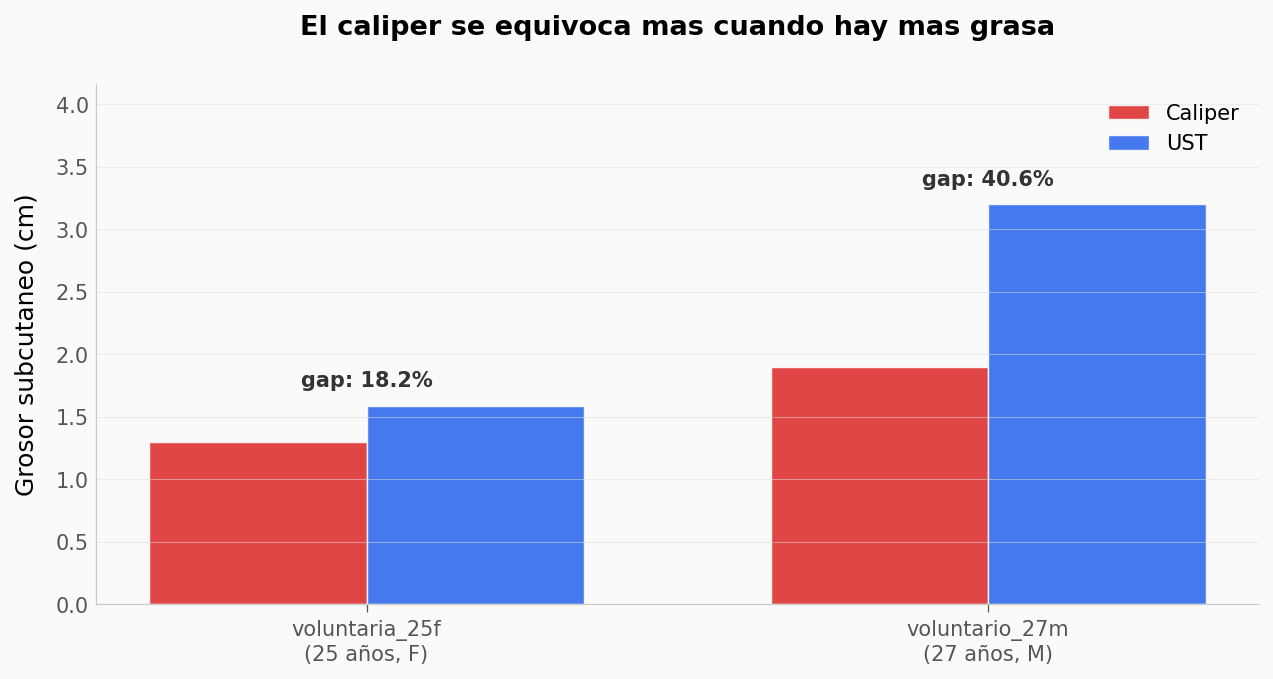

In [6]:
# --- EXPERIMENTA AQUI ---
# Pregunta 3: ¿el caliper es peor cuando hay mas grasa?

# Reestructurar para tener caliper y UST en columnas separadas por sujeto
pivote = calipers.pivot_table(index=['sujeto', 'edad', 'sexo'],
                               columns='metodo', values='grosor_cm').reset_index()
pivote['diferencia_cm'] = pivote['ust'] - pivote['caliper']
pivote['subestimacion_pct'] = pivote['diferencia_cm'] / pivote['ust'] * 100

print('Comparacion caliper vs UST por sujeto:')
print(pivote[['sujeto', 'edad', 'sexo', 'caliper', 'ust',
              'diferencia_cm', 'subestimacion_pct']].to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(pivote))
w = 0.35
ax.bar(x - w/2, pivote['caliper'], w, color=COLOR_ALERTA, alpha=0.85,
       edgecolor='white', linewidth=0.7, label='Caliper')
ax.bar(x + w/2, pivote['ust'], w, color=COLOR_DATOS, alpha=0.85,
       edgecolor='white', linewidth=0.7, label='UST')

for i, row in pivote.iterrows():
    ax.text(i, max(row['caliper'], row['ust']) + 0.15,
            f'gap: {row["subestimacion_pct"]:.1f}%',
            ha='center', fontsize=10, fontweight='bold', color='#333')

ax.set_xticks(x)
ax.set_xticklabels([f"{row['sujeto']}\n({row['edad']} años, {row['sexo']})"
                    for _, row in pivote.iterrows()])
ax.set_ylabel('Grosor subcutaneo (cm)')
ax.set_title('El caliper se equivoca mas cuando hay mas grasa',
             fontsize=13, fontweight='bold', pad=24)
ax.legend(fontsize=10)
ax.set_ylim(0, pivote['ust'].max() * 1.3)
plt.show()

# Observacion (n=2, no generalizable): en estos 2 sujetos, al crecer el grosor
# UST real crece tambien el % subestimado del caliper. Es consistente con la
# fisica (mas tejido = mas compresible = mas error al pellizcar), pero no es
# una regresion — harian falta mas sujetos para cuantificar el patron.

## Fuentes

**Paper**: [Whole cross-sectional human ultrasound tomography](https://doi.org/10.1038/s41551-026-01660-4)  
*Nature Biomedical Engineering, 2026-04-24*

**Supplementary Information**: [Tablas y figuras de validación (MOESM1)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01660-4/MediaObjects/41551_2026_1660_MOESM1_ESM.pdf)  
*Nature Biomedical Engineering — Supplementary Information*

**Dataset crudo** (no usado en este notebook por tamaño, 14 GB): [Human abdominal ultrasound tomography example dataset](https://doi.org/10.6084/m9.figshare.31043818.v2)  
*Figshare · CC BY 4.0*

*14 afirmaciones verificadas contra estas fuentes*

---

**Notebook**: [Ciencia a Mordiscos — Lab](https://github.com/Ciencia-a-Mordiscos/lab)
**Licencia**: datos del paper bajo los términos de Springer Nature (Supplementary Information). Código del notebook: CC BY 4.0.